# Two-guard / one-bandit demo (attitude + cone sensor)

This is a strict extension of `lbg_two_guard_pf_demo.ipynb`. Same
scenario (2 randomly-initialized guards + 1 lady-seeking bandit, PF
beliefs on both sides, cross-guard belief fusion hook), but with two
new physics layers added:

1. **Rigid-body attitude dynamics on the guards.** Each guard now
   carries a quaternion attitude state and body-frame angular rates,
   integrated by RK4 every step. The guards' initial body rate is set
   via `FixedAttitude`, and the guards have an `ATTITUDE_CONTROL`
   action component so the collaborator can command body-frame torque
   each step. The bandit keeps a passive identity attitude.

2. **Body-fixed cone sensor on the guards.** The guards' omnidirectional
   `RangeLimitedObservation` is replaced with `ConicalObservation` —
   visibility is gated by the target's line-of-sight angle to the
   body-fixed sensor boresights. The cones rotate with the guard, so
   *pointing* becomes a decision-relevant action: spin to scan a wide
   field, or hold to track a known target. The bandit keeps its
   omnidirectional range-limited sensor for asymmetry.

**Why this is interesting.** The `lbg_two_guard_pf_demo` baseline
tests information *gating by distance*. This notebook adds the
*pointing* decision: the guards' beliefs about the bandit collapse
only on ticks when the bandit is both inside the sensor cone AND
inside the cone's effective range. With a free-spinning IC the cones
sweep across the sky and beliefs collapse intermittently; with a
tracking heuristic (collaborator extension) they collapse durably.

All extension points from the baseline notebook still apply (search
for `EXTENSION POINT`); this notebook adds two more for attitude/cone
knobs.

CPU-only, like the other LBG notebooks.

In [1]:
# Pin CPU device before importing JAX. On Apple Silicon `jax-mps` may
# auto-register and become the default; the float64 reference-orbit
# arrays would then hit MLX and error.
import os

os.environ["JAX_DEFAULT_DEVICE"] = "cpu"

import sys
from pathlib import Path

_here = Path.cwd()
if (_here / "src" / "orbital_game").is_dir():
    _repo_root = _here
elif (_here.parent / "src" / "orbital_game").is_dir():
    _repo_root = _here.parent
else:
    raise RuntimeError(f"Could not locate orbital-game repo root from cwd={_here}")
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

%load_ext autoreload
%autoreload 2

from dataclasses import dataclass
from types import SimpleNamespace
from typing import Any

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from orbital_game import (
    Actions,
    BySide,
    OrbitalGameEnv,
    ScenarioConfig,
    Side,
    VehicleParamsSpec,
)
from orbital_game.belief import (
    ParticleFilterBeliefUpdater,
    ParticleFilterRingInitializer,
    PFTeamFusion,
)
from orbital_game.dynamics.attitude import AttitudeParams
from orbital_game.dynamics.hcw import hcw_rt_step
from orbital_game.games.lady_bandit_guard import LadyBanditGuard
from orbital_game.observations.conical import ConicalObservation
from orbital_game.observations.negative_info import Hard
from orbital_game.policies.zero import ZeroControl
from orbital_game.reference_orbit import (
    ReferenceOrbitState,
)
from orbital_game.reference_orbit import (
    mean_motion as ref_mean_motion,
)
from orbital_game.registry import (
    ActionComponentKey,
    AttitudeDynamicsKey,
    DynamicsKey,
    Frame,
    StateComponentKey,
)
from orbital_game.sampling.attitude import FixedAttitude
from orbital_game.sampling.mass import ConstantMass
from orbital_game.sampling.side import RelativeEllipse
from orbital_game.sampling.spec import ICSpec
from orbital_game.termination.lbg_events import LbgEventTermination
from orbital_game.termination.max_distance import AnyOfTermination, MaxDistanceTermination

# HCW-LQR helpers used to build the lady-seeking bandit controller in section 3.
sys.path.insert(0, str(_repo_root / "examples"))
from policies.lqr_bandit import _build_horizon_matrices, _hcw_rt_AB  # noqa: E402

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Platform 'mps' is experimental and not all JAX functionality may be correctly supported!


## 1. Knobs — TUNE THIS CELL

Same structure as the baseline notebook, plus two new sections at
the bottom for **attitude** and **cone sensor** parameters.

In [2]:
# ---- Geometry ---------------------------------------------------------------
RING_RADIUS_M = 2000.0
GUARD_RING_RADIUS_M = 200.0

# ---- Sensor parameters (per side) -------------------------------------------
# Both sides now use body-fixed cone sensors. Bandit-side cone knobs
# live in section 1b below alongside the guard-side ones, so the
# scenario is symmetric: each side has to point to see.

# ---- Capture / breach radii -------------------------------------------------
CATCH_RADIUS_M = 50.0
BREACH_RADIUS_M = 5.0

# ---- Runaway-drift cap -------------------------------------------------------
MAX_DISTANCE_TERMINATION_M = 10000.0

# ---- Bandit thrust authority ------------------------------------------------
BANDIT_MAX_DV_MPS = 0.5

# ---- Time / horizon ----------------------------------------------------------
DT = 10.0
MAX_HORIZON_S = 4500.0

# ---- Particle filter ---------------------------------------------------------
N_PARTICLES = 256
PROCESS_NOISE_DIAG = jnp.array([1.0, 1.0, 1e-3, 1e-3])  # (r, t, rdot, tdot)

# ---- Fleet sizing ------------------------------------------------------------
N_GUARDS = 2
N_BANDITS = 1

# ---- Reference orbit ---------------------------------------------------------
ref_orbit = ReferenceOrbitState(
    position_eci=jnp.array([7000e3, 0.0, 0.0]),
    velocity_eci=jnp.array([0.0, 7.5e3, 0.0]),
)
N_MOTION = float(ref_mean_motion(ref_orbit))

### 1a. EXTENSION POINT — Attitude dynamics knobs

`AttitudeParams.inertia_diag` is the principal-axis inertia tensor
(kg·m²); `omega_max` is the per-axis reaction-wheel saturation
(rad/s). With HCW_RT (2-D in-plane dynamics) only body-z rotation
matters — bodies stay nominally aligned with the orbital plane —
but the cone math is 3-D so the framework still tracks the full
quaternion + 3-axis ω.

`GUARD_INITIAL_SPIN_DPS` sets each guard's body-z spin rate at the
initial condition. With a free spin the cones sweep around the
spacecraft over time, so the bandit cycles in and out of view at
the spin period — visible in the section-9 variance trace.

In [3]:
GUARD_INERTIA_KG_M2 = (10.0, 10.0, 5.0)  # (Ix, Iy, Iz) for the guard bus
GUARD_OMEGA_MAX_RAD_S = (0.0, 0.0, 0.5)  # body-z saturation; in-plane motion only
GUARD_INITIAL_SPIN_DPS = 1.0  # initial body-z rate (deg/s) for both guards

guard_attitude_params = AttitudeParams(
    inertia_diag=jnp.array(GUARD_INERTIA_KG_M2, dtype=jnp.float32),
    omega_max=jnp.array(GUARD_OMEGA_MAX_RAD_S, dtype=jnp.float32),
)

# Initial attitude: identity quaternion + body-z spin. Both guards start
# at the same rate; their headings diverge over time because they sit
# at different ring phases (random per run). To randomize the initial
# orientation per guard, swap to `UniformAttitude()` from
# `orbital_game.sampling.attitude`.
guard_attitude_sampler = FixedAttitude(
    quat_wxyz=(1.0, 0.0, 0.0, 0.0),
    omega_rad_s=(0.0, 0.0, float(jnp.deg2rad(GUARD_INITIAL_SPIN_DPS))),
)

# ---- Bandit attitude IC -----------------------------------------------------
# Symmetric to the guards: bandit also has a body-z spin so its cone
# sensor sweeps. Default to a slower rate so the bandit's own coverage
# is more intermittent than the guards' — captures the "harder for the
# attacker to keep eyes on the defenders" asymmetry.
BANDIT_INITIAL_SPIN_DPS = 0.5
bandit_attitude_sampler = FixedAttitude(
    quat_wxyz=(1.0, 0.0, 0.0, 0.0),
    omega_rad_s=(0.0, 0.0, float(jnp.deg2rad(BANDIT_INITIAL_SPIN_DPS))),
)

### 1b. EXTENSION POINT — Cone sensor knobs

`GUARD_SENSOR_BORESIGHTS_BODY` is a `(k, 3)` array of unit vectors
in the spacecraft's body frame, defining the centerline of each
sensor cone. Add or remove rows to change the sensor footprint.
`GUARD_SENSOR_HALF_ANGLE_DEG` is the half-angle of each cone — small
values mean intermittent measurements and sharp PF collapse;
wide values approximate the omnidirectional baseline.

Default below: a **single +x body face** with a 30° half-angle. With
the guards spinning on body-z this is a "lighthouse" sensor — the
beam sweeps the sky once per spin period.

`GUARD_SIGMA_FULLSTATE` is the measurement noise; ConicalObservation
returns a full-state measurement (position AND velocity in one
vector), so this σ applies to all 4 components in the RT-plane state.

In [4]:
GUARD_SENSOR_BORESIGHTS_BODY = jnp.array(
    [[1.0, 0.0, 0.0]],  # single +x face
    dtype=jnp.float32,
)
GUARD_SENSOR_HALF_ANGLE_DEG = 30.0
GUARD_SIGMA_FULLSTATE = 5.0  # m on position; m/s on velocity

# Alternative configurations to try — uncomment to swap in:
# GUARD_SENSOR_BORESIGHTS_BODY = jnp.array([
#     [ 1.0,  0.0, 0.0],   # +x face
#     [ 0.0,  1.0, 0.0],   # +y face
#     [-1.0,  0.0, 0.0],   # -x face
#     [ 0.0, -1.0, 0.0],   # -y face
# ], dtype=jnp.float32)
# GUARD_SENSOR_HALF_ANGLE_DEG = 15.0    # narrower, four-face → tighter resolution

# ---- Bandit cone --------------------------------------------------------------
# Bandit's body-fixed cone fan and noise. Default: a wider single +x
# cone (60° half-angle) so the bandit's PF over the guards collapses
# more readily than the guards' PF over the bandit — captures the
# realistic asymmetry that the attacker's situational awareness is
# usually wider but lower-resolution than a tracked defender's.
BANDIT_SENSOR_BORESIGHTS_BODY = jnp.array(
    [[1.0, 0.0, 0.0]],
    dtype=jnp.float32,
)
BANDIT_SENSOR_HALF_ANGLE_DEG = 60.0
BANDIT_SIGMA_FULLSTATE = 10.0

print(
    f"guard sensor cones:  k={GUARD_SENSOR_BORESIGHTS_BODY.shape[0]}  "
    f"half-angle={GUARD_SENSOR_HALF_ANGLE_DEG:.1f}deg  sigma={GUARD_SIGMA_FULLSTATE:.1f}"
)
print(
    f"bandit sensor cones: k={BANDIT_SENSOR_BORESIGHTS_BODY.shape[0]}  "
    f"half-angle={BANDIT_SENSOR_HALF_ANGLE_DEG:.1f}deg  sigma={BANDIT_SIGMA_FULLSTATE:.1f}"
)
print(
    f"guard initial spin:  {GUARD_INITIAL_SPIN_DPS:.2f} deg/s about body-z   "
    f"(period ~ {360.0 / max(GUARD_INITIAL_SPIN_DPS, 1e-6):.0f} s)"
)
print(
    f"bandit initial spin: {BANDIT_INITIAL_SPIN_DPS:.2f} deg/s about body-z   "
    f"(period ~ {360.0 / max(BANDIT_INITIAL_SPIN_DPS, 1e-6):.0f} s)"
)

guard sensor cones:  k=1  half-angle=30.0deg  sigma=5.0
bandit sensor cones: k=1  half-angle=60.0deg  sigma=10.0
guard initial spin:  1.00 deg/s about body-z   (period ~ 360 s)
bandit initial spin: 0.50 deg/s about body-z   (period ~ 720 s)


## 2. Scenario builder

Same as the baseline, but with the guards' state expanded to include
`ATTITUDE` + `BODY_RATES`, the guards' action expanded to include
`ATTITUDE_CONTROL`, the rigid-body attitude integrator wired in, and
the guards' `attitude_sampler` set on the IC sampler.

In [5]:
def stratified_random_phases(seed: int, n: int) -> jnp.ndarray:
    """`n` evenly-spaced phases (2*pi/n apart), with a per-seed random rotation."""
    base = jax.random.uniform(jax.random.PRNGKey(seed), (), minval=0.0, maxval=2 * jnp.pi)
    return base + jnp.arange(n) * (2.0 * jnp.pi / n)


def make_cfg(*, guard_obs_fn=None, bandit_obs_fn=None, seed: int = 0):
    guard_phases = stratified_random_phases(seed, N_GUARDS)
    return ScenarioConfig(
        n_guards=N_GUARDS,
        n_bandits=N_BANDITS,
        epoch_mjd_utc=60067.0,
        reference_orbit=ref_orbit,
        guard_components=(
            StateComponentKey.RT,
            StateComponentKey.MASS,
            StateComponentKey.ATTITUDE,
            StateComponentKey.BODY_RATES,
        ),
        bandit_components=(
            StateComponentKey.RT,
            StateComponentKey.MASS,
            StateComponentKey.ATTITUDE,
            StateComponentKey.BODY_RATES,
        ),
        guard_params=VehicleParamsSpec(dry_mass_kg=12.0, isp_s=65.0, max_thrust_n=3.6),
        bandit_params=VehicleParamsSpec(dry_mass_kg=12.0, isp_s=65.0, max_thrust_n=3.6),
        ic_sampler=ICSpec(
            guard_sampler=RelativeEllipse(
                radial_ellipse_m=GUARD_RING_RADIUS_M,
                cross_track_m=0.0,
                along_track_offset_m=0.0,
                phase_rad=guard_phases,  # stratified random per seed
                mass_sampler=ConstantMass(propellant_mass_kg=3.0),
                attitude_sampler=guard_attitude_sampler,
            ),
            bandit_sampler=RelativeEllipse(
                radial_ellipse_m=RING_RADIUS_M,
                cross_track_m=0.0,
                along_track_offset_m=0.0,
                phase_rad=jnp.array([jnp.pi / 2.0]),  # max-distance phase
                mass_sampler=ConstantMass(propellant_mass_kg=3.0),
                attitude_sampler=bandit_attitude_sampler,
            ),
            validators=(),
            max_attempts=10,
        ),
        truth_dynamics=DynamicsKey.HCW_RT,
        policy_dynamics=DynamicsKey.HCW_RT,
        action_frame=Frame.RT,
        guard_action_components=(
            ActionComponentKey.ATTITUDE_CONTROL,
            ActionComponentKey.IMPULSIVE_MANEUVER,
        ),
        bandit_action_components=(ActionComponentKey.IMPULSIVE_MANEUVER,),
        attitude_dynamics_key=AttitudeDynamicsKey.RIGID_BODY,
        guard_attitude_params=guard_attitude_params,
        bandit_attitude_params=guard_attitude_params,  # reuse the same inertia for simplicity
        guard_observation_fn=guard_obs_fn,
        bandit_observation_fn=bandit_obs_fn,
        dt=DT,
        max_horizon_s=MAX_HORIZON_S,
        seed=seed,
        game=LadyBanditGuard(
            breach_radius_m=BREACH_RADIUS_M,
            catch_radius_m=CATCH_RADIUS_M,
        ),
        termination_fn=AnyOfTermination(
            [
                LbgEventTermination(
                    breach_radius_m=BREACH_RADIUS_M,
                    catch_radius_m=CATCH_RADIUS_M,
                ),
                MaxDistanceTermination(max_distance_m=MAX_DISTANCE_TERMINATION_M),
            ]
        ),
    )


# Build a proto config to read .layout, then attach observation fns.
proto_layout = OrbitalGameEnv(make_cfg()).layout

guard_obs_fn = ConicalObservation(
    layout=proto_layout,
    sensor_boresights_body=GUARD_SENSOR_BORESIGHTS_BODY,
    half_angle_rad=float(jnp.deg2rad(GUARD_SENSOR_HALF_ANGLE_DEG)),
    sigma=GUARD_SIGMA_FULLSTATE,
)
bandit_obs_fn = ConicalObservation(
    layout=proto_layout,
    sensor_boresights_body=BANDIT_SENSOR_BORESIGHTS_BODY,
    half_angle_rad=float(jnp.deg2rad(BANDIT_SENSOR_HALF_ANGLE_DEG)),
    sigma=BANDIT_SIGMA_FULLSTATE,
)
cfg = make_cfg(guard_obs_fn=guard_obs_fn, bandit_obs_fn=bandit_obs_fn)
env = OrbitalGameEnv(cfg)
print(f"guard command fields: {list(env.guard_command_cls.zeros(1).__dataclass_fields__.keys())}")
print(f"bandit command fields: {list(env.bandit_command_cls.zeros(1).__dataclass_fields__.keys())}")
print(
    f"flat state dim: {env.layout.flat_dim}    dynamics_state_dim: {env.layout.dynamics_state_dim}"
)

guard command fields: ['torque', 'dv']
bandit command fields: ['dv']
flat state dim: 54    dynamics_state_dim: 4


## 3. EXTENSION POINT — Bandit policy: drive toward the lady (HCW-aware LQR)

Same as the baseline notebook: a closed-form HCW LQR that minimizes
terminal position-magnitude. A naïve "thrust-toward-origin" rule
*fails* under HCW dynamics — Coriolis coupling drives secular
along-track drift away from the origin even when the thrust vector
points inward. The LQR explicitly solves for the right action over
the discrete-time HCW model.

In [6]:
@dataclass(frozen=True)
class LQRGoToLadyPolicy:
    """HCW-aware LQR controller driving the bandit toward the lady (RTN origin)."""

    gain: jax.Array
    max_dv_mps: float = 0.05
    n_vehicles: int = 1
    command_cls: Any = None

    @classmethod
    def build(
        cls,
        *,
        mean_motion,
        dt,
        horizon=8,
        control_cost=1e-3,
        max_dv_mps=0.05,
        n_vehicles=1,
        command_cls=None,
    ):
        A, B = _hcw_rt_AB(mean_motion, dt)  # noqa: N806
        A_powH, M = _build_horizon_matrices(A, B, horizon)  # noqa: N806
        C = jnp.array([[1.0, 0.0, 0.0, 0.0], [0.0, 1.0, 0.0, 0.0]])  # noqa: N806
        H_lam = M.T @ C.T @ C @ M + control_cost * jnp.eye(M.shape[1])  # noqa: N806
        K = jnp.linalg.solve(H_lam, M.T @ C.T @ C @ A_powH)  # noqa: N806
        gain = K[:2, :]
        return cls(
            gain=gain,
            max_dv_mps=max_dv_mps,
            n_vehicles=n_vehicles,
            command_cls=command_cls,
        )

    def __call__(self, policy_state, agent_view, key, t):
        del key, t
        if self.command_cls is None:
            raise ValueError("LQRGoToLadyPolicy was constructed without command_cls.")
        dvs_unclipped = -agent_view @ self.gain.T
        dvs = jnp.clip(dvs_unclipped, -self.max_dv_mps, self.max_dv_mps)
        cmd_template = self.command_cls.zeros(self.n_vehicles)
        return cmd_template.replace(dv=dvs), policy_state


bandit_policy = LQRGoToLadyPolicy.build(
    mean_motion=N_MOTION,
    dt=cfg.dt,
    horizon=8,
    control_cost=1e-3,
    max_dv_mps=BANDIT_MAX_DV_MPS,
    n_vehicles=cfg.n_bandits,
    command_cls=env.bandit_command_cls,
)

## 4. EXTENSION POINT — Guard policy: passive spin (default) or scan/track

The default guard policy is **`ZeroControl`** — zero torque AND zero
Δv. The guards' attitude evolves passively from the IC body rate set
in section 1a, which means the cones rotate at the IC rate forever.
With the default `1 deg/s` spin and a single 30°-half-angle face,
the bandit is in view roughly `60 / 360 = 17%` of every spin period
(when the bandit is inside the cone's effective range).

**The "scan vs track" tradeoff this introduces.** Because torque is
now an action variable, the collaborator can write a heuristic that
(a) computes the angle from the +x body-axis to the cross-pair belief
mean, (b) commands torque proportional to that angle (clipped to
`omega_max`). With a `Hard` negative-info gate, doing so collapses
the PF posterior onto the bandit and keeps it collapsed. The tradeoff
is that other directions become unobservable — important when there
is more than one bandit (a future extension).

Drop-in replacements:

- **A scanner heuristic** — sweep ω at a fixed nonzero rate (the
  default already does this via the IC body rate, but the
  collaborator could vary the rate over time as a function of belief
  entropy: spin fast when uncertain, lock heading when confident).
- **A pointing controller** — proportional + derivative on heading
  error to the cross-pair belief mean. The `command_cls` exposes
  `torque` and `dv` fields independently, so a pointer that doesn't
  thrust just leaves `dv=0`.
- **An MCTS pointing policy** — branch on torque commands; reward is
  the post-update PF variance reduction.

In [7]:
guard_policy = ZeroControl(
    n_vehicles=cfg.n_guards,
    command_cls=env.guard_command_cls,
)

## 5. Particle-filter beliefs (per side)

Same shapes as the baseline — the PF only sees the 4-D RT state, not
the attitude axes. Beliefs are unaffected by adding attitude.

Note that ConicalObservation returns a *full-state* measurement
(`m = d = 4`), so the PF assimilates RT-frame velocity in addition
to position. RangeLimitedObservation on the bandit side is still
position-only (`m = 3`). The PF updater handles both layouts via
the per-channel `obs_matrix` field.

In [8]:
def per_vehicle_hcw_rt(x, u, dt):
    return hcw_rt_step(x[None, :], u[None, :], SimpleNamespace(mean_motion=N_MOTION), dt)[0]


negative_info_mode = Hard()  # crush in-cone-but-no-detection particles

guard_pf_updater = ParticleFilterBeliefUpdater(
    dynamics_fn=per_vehicle_hcw_rt,
    process_noise=jnp.diag(PROCESS_NOISE_DIAG),
    dt=cfg.dt,
    n_eff_threshold=0.5,
    resample_jitter_scale=0.05,
    negative_info=negative_info_mode,
)
bandit_pf_updater = ParticleFilterBeliefUpdater(
    dynamics_fn=per_vehicle_hcw_rt,
    process_noise=jnp.diag(PROCESS_NOISE_DIAG),
    dt=cfg.dt,
    n_eff_threshold=0.5,
    resample_jitter_scale=0.05,
    negative_info=negative_info_mode,
)
guard_pf_init = ParticleFilterRingInitializer(
    layout=env.layout,
    ring_radius_m=RING_RADIUS_M,
    mean_motion_rad_s=N_MOTION,
    n_particles=N_PARTICLES,
)
bandit_pf_init = ParticleFilterRingInitializer(
    layout=env.layout,
    ring_radius_m=GUARD_RING_RADIUS_M,
    mean_motion_rad_s=N_MOTION,
    n_particles=N_PARTICLES,
)

## 6. EXTENSION POINT — Reward function

Default reward (`LbgZeroSumReward`) is unchanged from the baseline.
To **add a torque-budget penalty** so the collaborator's pointing
heuristic can't spin arbitrarily aggressively, build a custom reward
that subtracts `λ * ||torque||²` and pass it as `reward_fn=` to the
`ScenarioConfig` constructor. The torque value is on
`actions.sides.guard.torque` — the reward fn already receives
`action` as its second argument.

In [9]:
print(f"reward_fn: {cfg.reward_fn.__class__.__name__}")
print(f"  catch_radius_m  = {cfg.reward_fn.catch_radius_m:g}")
print(f"  breach_radius_m = {cfg.reward_fn.breach_radius_m:g}")
print(f"termination_fn: {cfg.termination_fn.__class__.__name__}")

reward_fn: LbgZeroSumReward
  catch_radius_m  = 50
  breach_radius_m = 5
termination_fn: AnyOfTermination


## 7. Manual rollout with belief tracking

Same loop structure as the baseline. The only difference: the guard
command pytree now carries both `torque` and `dv`; `ZeroControl.zeros`
initializes both to zero so this loop works unchanged.

In [10]:
n_steps = int(cfg.max_horizon_s / cfg.dt)

key = jax.random.PRNGKey(7)
key, k_reset, k_g_init, k_b_init = jax.random.split(key, 4)
state, _ = env.reset(k_reset)
guard_belief = guard_pf_init(state, Side.GUARD, k_g_init)
bandit_belief = bandit_pf_init(state, Side.BANDIT, k_b_init)

states_over_time = [state]
guard_beliefs_over_time = [guard_belief]
bandit_beliefs_over_time = [bandit_belief]
guard_actions_list = []
bandit_actions_list = []
guard_visible_per_observer = []  # per-step (n_guards,) bool — did each guard see the bandit?
caught_at_step = -1
breached_at_step = -1
max_distance_at_step = -1
termination_reason = "truncated_max_steps"
guard_rewards_over_time = []
bandit_rewards_over_time = []

for step in range(n_steps):
    key, k_g, k_b, k_env, k_g_obs, k_b_obs, k_g_pf, k_b_pf = jax.random.split(key, 8)

    g_action, _ = guard_policy(None, None, k_g, state.t)
    b_view = state.bandits.rt
    b_action, _ = bandit_policy(None, b_view, k_b, state.t)

    actions = Actions(sides=BySide(guard=g_action, bandit=b_action))
    step_out = env.step(k_env, state, actions)
    next_state = step_out.state

    guard_obs = env.guard_observation_fn(
        next_state,
        actions,
        Side.GUARD,
        env.config,
        k_g_obs,
        next_state.t,
    )
    bandit_obs = env.bandit_observation_fn(
        next_state,
        actions,
        Side.BANDIT,
        env.config,
        k_b_obs,
        next_state.t,
    )
    guard_belief = guard_pf_updater(guard_belief, guard_obs, g_action.dv, Side.GUARD, k_g_pf)
    bandit_belief = bandit_pf_updater(bandit_belief, bandit_obs, b_action.dv, Side.BANDIT, k_b_pf)

    bandit_visible_mask = guard_obs[0].visible[:, cfg.n_guards :]  # (n_g, n_b)
    guard_visible_per_observer.append(np.asarray(bandit_visible_mask.any(axis=-1)))

    state = next_state
    states_over_time.append(state)
    guard_beliefs_over_time.append(guard_belief)
    bandit_beliefs_over_time.append(bandit_belief)
    guard_actions_list.append(g_action)
    bandit_actions_list.append(b_action)
    guard_rewards_over_time.append(float(step_out.outputs.guard.reward))
    bandit_rewards_over_time.append(float(step_out.outputs.bandit.reward))

    g_pos = state.guards.rt[:, :2]
    b_pos = state.bandits.rt[:, :2]
    d_gb_min = float(jnp.min(jnp.linalg.norm(g_pos[:, None, :] - b_pos[None, :, :], axis=-1)))
    d_bl_min = float(jnp.min(jnp.linalg.norm(b_pos, axis=-1)))
    all_pos = jnp.concatenate([g_pos, b_pos], axis=0)
    d_far_max = float(jnp.max(jnp.linalg.norm(all_pos, axis=-1)))
    if caught_at_step < 0 and d_gb_min < cfg.reward_fn.catch_radius_m:
        caught_at_step = step
        termination_reason = "catch"
    if breached_at_step < 0 and d_bl_min < cfg.reward_fn.breach_radius_m:
        breached_at_step = step
        if termination_reason == "truncated_max_steps":
            termination_reason = "breach"
    if max_distance_at_step < 0 and d_far_max > MAX_DISTANCE_TERMINATION_M:
        max_distance_at_step = step
        if termination_reason == "truncated_max_steps":
            termination_reason = "max_distance"
    if bool(step_out.episode_done):
        break

guard_visible_per_observer = np.stack(guard_visible_per_observer, axis=0)  # (T, n_guards)

print(
    f"visible-step counts per guard: "
    f"{guard_visible_per_observer.sum(axis=0).tolist()} / {len(guard_actions_list)}"
)
print(f"cumulative guard reward:  {sum(guard_rewards_over_time):.3f}")
print(f"cumulative bandit reward: {sum(bandit_rewards_over_time):.3f}")
print(
    f"caught at step:    {caught_at_step}   (t = {caught_at_step * cfg.dt if caught_at_step >= 0 else -1:.0f} s)"
)
print(
    f"breached at step:  {breached_at_step}   (t = {breached_at_step * cfg.dt if breached_at_step >= 0 else -1:.0f} s)"
)
print(
    f"max-distance at:   {max_distance_at_step}   (t = {max_distance_at_step * cfg.dt if max_distance_at_step >= 0 else -1:.0f} s)"
)
print(f"termination reason: {termination_reason}")

visible-step counts per guard: [16, 20] / 93
cumulative guard reward:  -1115.199
cumulative bandit reward: 891.486
caught at step:    -1   (t = -1 s)
breached at step:  92   (t = 920 s)
max-distance at:   -1   (t = -1 s)
termination reason: breach


## 8. Visibility heatmap — when did each cone see the bandit?

Because the cones rotate at the IC body rate, each guard sees the
bandit periodically — once per spin period for a single-face cone,
k-times per spin period for a k-face cone. A pointing heuristic
would replace this periodic pattern with a denser stripe centered
on the bandit's apparent direction.

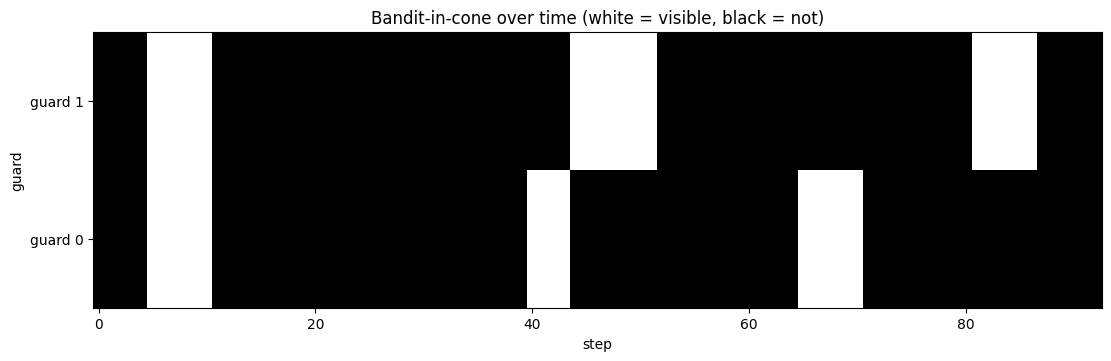

In [11]:
fig, ax = plt.subplots(figsize=(11, 2.5 + 0.5 * cfg.n_guards), constrained_layout=True)
ax.imshow(
    guard_visible_per_observer.T,
    aspect="auto",
    origin="lower",
    cmap="Greys_r",
    interpolation="nearest",
    vmin=0,
    vmax=1,
)
ax.set_xlabel("step")
ax.set_ylabel("guard")
ax.set_yticks(range(cfg.n_guards))
ax.set_yticklabels([f"guard {i}" for i in range(cfg.n_guards)])
ax.set_title("Bandit-in-cone over time (white = visible, black = not)")
plt.show()

## 9. EXTENSION POINT — Cross-guard belief fusion (the comms hook)

Same `PFTeamFusion` mechanism as the baseline. The contact mask here
is **not** "did the ground station see the bandit" but "did this
guard's cone see the bandit this tick" — a more natural model for
free-space optical or RF cross-link sharing where each guard can
broadcast its measurement immediately on detection.

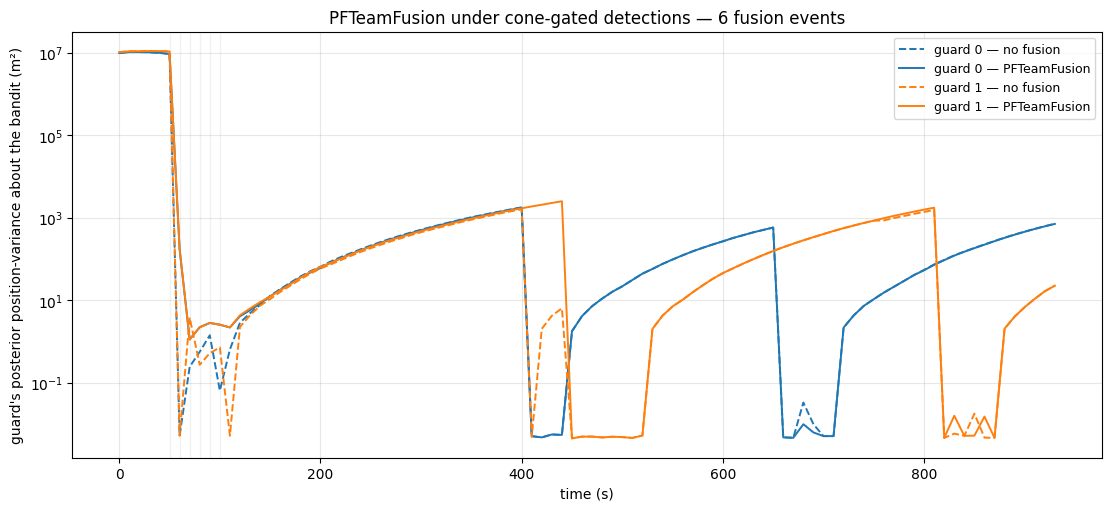

#fusion events: 6 (out of 450 ticks)


In [12]:
fuser = PFTeamFusion()


def _xpair_position_variance(belief, n_self, n_total):
    weights = jax.nn.softmax(belief.log_weights, axis=-1)
    mean = jnp.einsum("...k,...kd->...d", weights, belief.particles)
    diff = belief.particles - mean[..., None, :]
    sq = jnp.sum(diff[..., :2] * diff[..., :2], axis=-1)
    variance = jnp.einsum("...k,...k->...", weights, sq)
    return variance[:, n_self:]


# Match section 7's key splits so the env trajectories (and termination
# step) are identical between fused and unfused rollouts.
key_fuse = jax.random.PRNGKey(7)
key_fuse, k_reset_f, k_g_init_f, k_b_init_f = jax.random.split(key_fuse, 4)
state_f, _ = env.reset(k_reset_f)
belief_f = guard_pf_init(state_f, Side.GUARD, k_g_init_f)

fused_var_trace = [
    np.asarray(_xpair_position_variance(belief_f, cfg.n_guards, cfg.n_guards + cfg.n_bandits))
]
fusion_events = []
for step in range(n_steps):
    key_fuse, k_g, k_b, k_env, k_g_obs, k_b_obs, k_g_pf, k_b_pf = jax.random.split(key_fuse, 8)
    g_action, _ = guard_policy(None, None, k_g, state_f.t)
    b_action, _ = bandit_policy(None, state_f.bandits.rt, k_b, state_f.t)
    actions = Actions(sides=BySide(guard=g_action, bandit=b_action))
    step_out = env.step(k_env, state_f, actions)
    next_state = step_out.state
    obs = env.guard_observation_fn(
        next_state,
        actions,
        Side.GUARD,
        env.config,
        k_g_obs,
        next_state.t,
    )
    belief_f = guard_pf_updater(belief_f, obs, g_action.dv, Side.GUARD, k_g_pf)
    contact = obs[0].visible[:, cfg.n_guards :].any(axis=-1)
    if bool(contact.sum() > 1):
        belief_f = fuser(belief_f, contact)
        fusion_events.append(step)
    state_f = next_state
    fused_var_trace.append(
        np.asarray(_xpair_position_variance(belief_f, cfg.n_guards, cfg.n_guards + cfg.n_bandits))
    )
    if bool(step_out.episode_done):
        break

unfused_var_trace = np.stack(
    [
        np.asarray(_xpair_position_variance(b, cfg.n_guards, cfg.n_guards + cfg.n_bandits))
        for b in guard_beliefs_over_time
    ],
    axis=0,
)
fused_var_trace = np.stack(fused_var_trace, axis=0)
t_axis = np.arange(unfused_var_trace.shape[0]) * cfg.dt

fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)
for gi in range(cfg.n_guards):
    ax.plot(
        t_axis,
        unfused_var_trace[:, gi, 0],
        color=f"C{gi}",
        linestyle="--",
        linewidth=1.4,
        label=f"guard {gi} — no fusion",
    )
    ax.plot(
        t_axis,
        fused_var_trace[:, gi, 0],
        color=f"C{gi}",
        linestyle="-",
        linewidth=1.4,
        label=f"guard {gi} — PFTeamFusion",
    )
for ev in fusion_events:
    ax.axvline(ev * cfg.dt, color="C7", alpha=0.10, linewidth=1.0)
ax.set_yscale("log")
ax.set_xlabel("time (s)")
ax.set_ylabel("guard's posterior position-variance about the bandit (m²)")
ax.set_title(f"PFTeamFusion under cone-gated detections — {len(fusion_events)} fusion events")
ax.legend(loc="best", fontsize=9)
ax.grid(alpha=0.3, which="both")
plt.show()

print(f"#fusion events: {len(fusion_events)} (out of {n_steps} ticks)")

## 10. Animation — multi-guard PF cloud + cone overlays

`RolloutScene.show_sensor_cones=True` reads each side's quaternion
at every frame and draws the body-fixed cone faces rotated into the
RT plane. The cones rotate at the IC body rate. Both **guards'**
particle clouds about the bandit AND the **bandit's** clouds about
each guard render, so you can directly see the correspondence
between a "cone sweeps over the target" event and the corresponding
PF collapse on that side.

**Why the cloud lags the truth.** Same as the baseline notebook:
each side's PF predicts the *opposing* side under zero-control HCW,
because that side's actions are unobserved. The bandit's HCW-LQR
thrust pulls it off the natural-motion ring while the guards' PF
rides the ring. Even continuous in-cone detection only reels the
cloud in over multiple consecutive ticks (because process noise is
small relative to a multi-tick dynamics-mismatch drift). To shrink
the lag, increase `PROCESS_NOISE_DIAG`, widen the cone half-angle,
or — for the bandit's belief about a thrusting guard — pass the
guard's `dv` to the bandit-side PF prediction (the guards run
`ZeroControl` here, so this is currently a no-op).

In [13]:
from orbital_game.env.types import SideTrajectory, Trajectory
from orbital_game.viz.animation import RolloutScene, save_animation

states_for_traj = states_over_time[:-1]
guard_beliefs_for_traj = guard_beliefs_over_time[:-1]
bandit_beliefs_for_traj = bandit_beliefs_over_time[:-1]

env_state_stacked = jax.tree_util.tree_map(lambda *xs: jnp.stack(xs, axis=0), *states_for_traj)
guard_actions_stacked = jax.tree_util.tree_map(
    lambda *xs: jnp.stack(xs, axis=0),
    *guard_actions_list,
)
bandit_actions_stacked = jax.tree_util.tree_map(
    lambda *xs: jnp.stack(xs, axis=0),
    *bandit_actions_list,
)
guard_belief_stacked = jax.tree_util.tree_map(
    lambda *xs: jnp.stack(xs, axis=0),
    *guard_beliefs_for_traj,
)
bandit_belief_stacked = jax.tree_util.tree_map(
    lambda *xs: jnp.stack(xs, axis=0),
    *bandit_beliefs_for_traj,
)

T = guard_actions_stacked.dv.shape[0]
empty_obs = jnp.zeros((T, 1))
zeros_T = jnp.zeros(T)
done_T = jnp.zeros(T, dtype=bool)

traj_for_anim = Trajectory(
    env_state=env_state_stacked,
    sides=BySide(
        guard=SideTrajectory(
            obs=empty_obs,
            action=guard_actions_stacked,
            reward=zeros_T,
            done=done_T,
            policy_state=None,
        ),
        bandit=SideTrajectory(
            obs=empty_obs,
            action=bandit_actions_stacked,
            reward=zeros_T,
            done=done_T,
            policy_state=None,
        ),
    ),
    episode_done=done_T,
    controlled_side=Side.GUARD,
)
belief_history_for_anim = BySide(guard=guard_belief_stacked, bandit=bandit_belief_stacked)

scene = RolloutScene(
    traj=traj_for_anim,
    cfg=cfg,
    dt=cfg.dt,
    mode="2d",
    show_trail=True,
    show_cubes=True,
    show_sensor_cones=True,  # cones rotate with the guards
    show_sensor_range=True,  # bandit's omnidirectional disc still drawn
    show_thrust=True,
    show_belief=True,
    belief_history=belief_history_for_anim,
    belief_particle_size=6.0,
    belief_particle_alpha_min=0.04,
    belief_particle_alpha_max=0.7,
    title_prefix="LBG 2-guard attitude+cone — ",
    figsize=(8.5, 7.0),
)
print(
    f"frames = {scene.n_frames}, axis_limit = {scene.axis_limit_m:.0f} m, mode = {scene.resolved_mode}"
)

out_dir = _repo_root / "outputs"
out_dir.mkdir(exist_ok=True)
out_path = out_dir / "lbg_two_guard_pf_demo_attitude_cone.mp4"
save_animation(scene, str(out_path), fps=12, dpi=110)
print(f"Saved animation to {out_path}")

from IPython.display import Video

Video(str(out_path), embed=False)

frames = 93, axis_limit = 4400 m, mode = 2d
Saved animation to /Users/duncan/repos/orbital-game/outputs/lbg_two_guard_pf_demo_attitude_cone.mp4


## 11. Multi-rollout statistics

Same harness as the baseline notebook's section 11, applied to the
attitude+cone variant. Run `N_ROLLOUTS` independent episodes (each
with a different seed -> different stratified-random guard phases ->
different cone-sweep alignments) and aggregate. Useful both as a
sanity check on the configured cone geometry and as a baseline
against which a pointing-controller heuristic can be compared.

In [ ]:
N_ROLLOUTS = 20
CLOSE_ENCOUNTER_RADIUS_M = CATCH_RADIUS_M * 5.0
CLOSE_TO_LADY_RADIUS_M = BREACH_RADIUS_M * 5.0


def run_one_episode(seed: int):
    cfg_seed = make_cfg(guard_obs_fn=guard_obs_fn, bandit_obs_fn=bandit_obs_fn, seed=seed)
    env_seed = OrbitalGameEnv(cfg_seed)
    bandit_policy_seed = LQRGoToLadyPolicy.build(
        mean_motion=N_MOTION,
        dt=cfg_seed.dt,
        horizon=8,
        control_cost=1e-3,
        max_dv_mps=BANDIT_MAX_DV_MPS,
        n_vehicles=cfg_seed.n_bandits,
        command_cls=env_seed.bandit_command_cls,
    )
    guard_policy_seed = ZeroControl(
        n_vehicles=cfg_seed.n_guards,
        command_cls=env_seed.guard_command_cls,
    )

    key = jax.random.PRNGKey(seed)
    key, k_reset, k_g_init, k_b_init = jax.random.split(key, 4)
    state, _ = env_seed.reset(k_reset)
    guard_belief = guard_pf_init(state, Side.GUARD, k_g_init)
    bandit_belief = bandit_pf_init(state, Side.BANDIT, k_b_init)

    n_steps_local = int(cfg_seed.max_horizon_s / cfg_seed.dt)
    min_d_gb = float("inf")
    min_d_bl = float("inf")
    n_close_encounters = 0
    n_close_to_lady = 0
    n_in_cone_steps = 0
    cum_guard_reward = 0.0
    cum_bandit_reward = 0.0
    termination = "truncated_max_steps"
    final_step = n_steps_local
    for step in range(n_steps_local):
        key, k_g, k_b, k_env, k_g_obs, k_b_obs, k_g_pf, k_b_pf = jax.random.split(key, 8)
        g_action, _ = guard_policy_seed(None, None, k_g, state.t)
        b_action, _ = bandit_policy_seed(None, state.bandits.rt, k_b, state.t)
        actions = Actions(sides=BySide(guard=g_action, bandit=b_action))
        step_out = env_seed.step(k_env, state, actions)
        next_state = step_out.state

        g_obs = env_seed.guard_observation_fn(
            next_state,
            actions,
            Side.GUARD,
            env_seed.config,
            k_g_obs,
            next_state.t,
        )
        b_obs = env_seed.bandit_observation_fn(
            next_state,
            actions,
            Side.BANDIT,
            env_seed.config,
            k_b_obs,
            next_state.t,
        )
        guard_belief = guard_pf_updater(guard_belief, g_obs, g_action.dv, Side.GUARD, k_g_pf)
        bandit_belief = bandit_pf_updater(bandit_belief, b_obs, b_action.dv, Side.BANDIT, k_b_pf)

        # Per-tick cone-detection counter.
        if bool(g_obs[0].visible[:, cfg_seed.n_guards :].any()):
            n_in_cone_steps += 1

        state = next_state
        cum_guard_reward += float(step_out.outputs.guard.reward)
        cum_bandit_reward += float(step_out.outputs.bandit.reward)

        g_pos = state.guards.rt[:, :2]
        b_pos = state.bandits.rt[:, :2]
        d_gb = float(jnp.min(jnp.linalg.norm(g_pos[:, None, :] - b_pos[None, :, :], axis=-1)))
        d_bl = float(jnp.min(jnp.linalg.norm(b_pos, axis=-1)))
        all_pos = jnp.concatenate([g_pos, b_pos], axis=0)
        d_far = float(jnp.max(jnp.linalg.norm(all_pos, axis=-1)))
        if d_gb < min_d_gb:
            min_d_gb = d_gb
        if d_bl < min_d_bl:
            min_d_bl = d_bl
        if d_gb < CLOSE_ENCOUNTER_RADIUS_M:
            n_close_encounters += 1
        if d_bl < CLOSE_TO_LADY_RADIUS_M:
            n_close_to_lady += 1
        if termination == "truncated_max_steps":
            if d_gb < cfg_seed.reward_fn.catch_radius_m:
                termination = "catch"
            elif d_bl < cfg_seed.reward_fn.breach_radius_m:
                termination = "breach"
            elif d_far > MAX_DISTANCE_TERMINATION_M:
                termination = "max_distance"
        if bool(step_out.episode_done):
            final_step = step + 1
            break

    return {
        "seed": seed,
        "min_d_gb": min_d_gb,
        "min_d_bl": min_d_bl,
        "n_close_encounters": n_close_encounters,
        "n_close_to_lady": n_close_to_lady,
        "n_in_cone_steps": n_in_cone_steps,
        "cum_guard_reward": cum_guard_reward,
        "cum_bandit_reward": cum_bandit_reward,
        "termination": termination,
        "final_step": final_step,
    }


import time

t0 = time.time()
episode_stats = [run_one_episode(seed) for seed in range(N_ROLLOUTS)]
t1 = time.time()
print(f"Ran {N_ROLLOUTS} episodes in {t1 - t0:.1f}s ({(t1 - t0) / N_ROLLOUTS:.2f} s/episode).")

### 11a. Termination breakdown

In [ ]:
from collections import Counter

term_counter = Counter(e["termination"] for e in episode_stats)
total = sum(term_counter.values())
print("Termination outcomes (count -- fraction):")
for reason in ("catch", "breach", "max_distance", "truncated_max_steps"):
    n = term_counter.get(reason, 0)
    print(f"  {reason:24s} {n:4d}   {n / total:5.1%}")

Termination outcomes (count -- fraction):
  catch                       4   20.0%
  breach                     16   80.0%
  max_distance                0    0.0%
  truncated_max_steps         0    0.0%


### 11b. Per-episode distance + cone-detection statistics

In addition to the baseline's distance histograms, the cone variant
also exposes `n_in_cone_steps` per episode — the count of ticks
during which any guard's cone caught the bandit. With a pointing
heuristic this number should grow toward `final_step` (always-tracking)
from its passive-spin baseline of roughly `final_step * cone_solid_angle`.

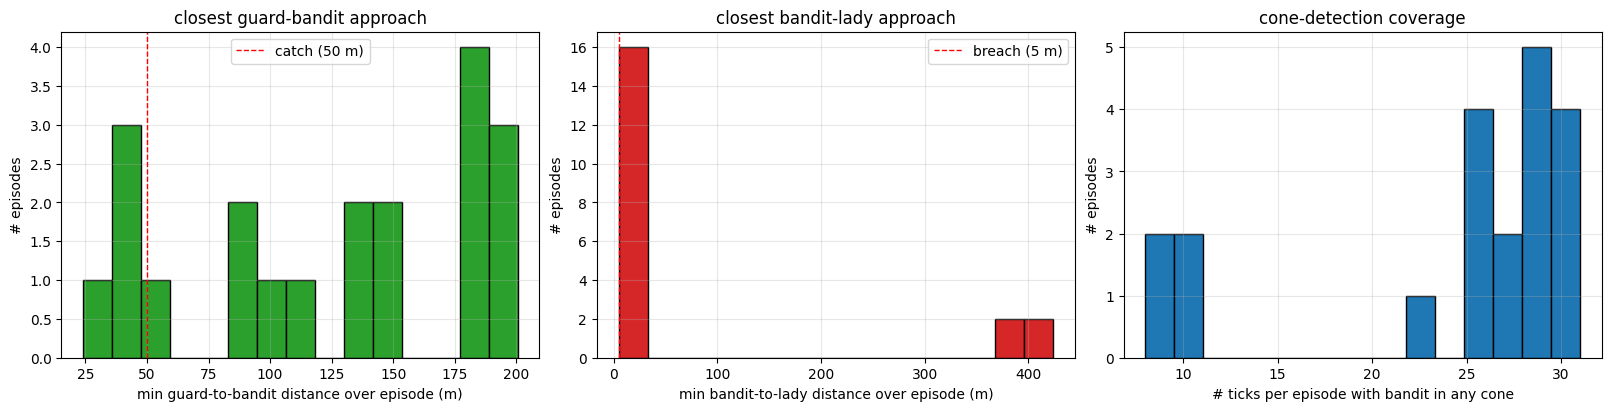

min guard-to-bandit (mean):   124.6 m  (std 59.8)
min bandit-to-lady  (mean):   83.3 m  (std 157.2)
#close encounters (mean):     22.6  (within 250 m)
#close-to-lady (mean):        17.6  (within 25 m)
#in-cone ticks (mean):        24.0
mean episode length: 83 steps


In [ ]:
min_d_gb_arr = np.array([e["min_d_gb"] for e in episode_stats])
min_d_bl_arr = np.array([e["min_d_bl"] for e in episode_stats])
n_close_enc_arr = np.array([e["n_close_encounters"] for e in episode_stats])
n_close_lady_arr = np.array([e["n_close_to_lady"] for e in episode_stats])
n_in_cone_arr = np.array([e["n_in_cone_steps"] for e in episode_stats])
final_step_arr = np.array([e["final_step"] for e in episode_stats])

fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)
axes[0].hist(min_d_gb_arr, bins=15, color="C2", edgecolor="black")
axes[0].axvline(
    CATCH_RADIUS_M,
    color="red",
    linestyle="--",
    linewidth=1.0,
    label=f"catch ({CATCH_RADIUS_M:.0f} m)",
)
axes[0].set_xlabel("min guard-to-bandit distance over episode (m)")
axes[0].set_ylabel("# episodes")
axes[0].set_title("closest guard-bandit approach")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(min_d_bl_arr, bins=15, color="C3", edgecolor="black")
axes[1].axvline(
    BREACH_RADIUS_M,
    color="red",
    linestyle="--",
    linewidth=1.0,
    label=f"breach ({BREACH_RADIUS_M:.0f} m)",
)
axes[1].set_xlabel("min bandit-to-lady distance over episode (m)")
axes[1].set_ylabel("# episodes")
axes[1].set_title("closest bandit-lady approach")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].hist(n_in_cone_arr, bins=15, color="C0", edgecolor="black")
axes[2].set_xlabel("# ticks per episode with bandit in any cone")
axes[2].set_ylabel("# episodes")
axes[2].set_title("cone-detection coverage")
axes[2].grid(alpha=0.3)
plt.show()

print(f"min guard-to-bandit (mean):   {min_d_gb_arr.mean():.1f} m  (std {min_d_gb_arr.std():.1f})")
print(f"min bandit-to-lady  (mean):   {min_d_bl_arr.mean():.1f} m  (std {min_d_bl_arr.std():.1f})")
print(
    f"#close encounters (mean):     {n_close_enc_arr.mean():.1f}  (within {CLOSE_ENCOUNTER_RADIUS_M:.0f} m)"
)
print(
    f"#close-to-lady (mean):        {n_close_lady_arr.mean():.1f}  (within {CLOSE_TO_LADY_RADIUS_M:.0f} m)"
)
print(f"#in-cone ticks (mean):        {n_in_cone_arr.mean():.1f}")
print(f"mean episode length: {final_step_arr.mean():.0f} steps")

## 12. Suggested experiments for collaborators

In addition to the experiments listed in the baseline notebook:

- **Spin-rate sweep.** Change `GUARD_INITIAL_SPIN_DPS` to 0, 0.1,
  1.0, 10.0 deg/s and observe the section-9 fusion-variance trace.
  Faster spins give shorter visibility windows but more frequent
  collapse events.

- **Cone-shape sweep.** Add or remove rows from
  `GUARD_SENSOR_BORESIGHTS_BODY` and adjust
  `GUARD_SENSOR_HALF_ANGLE_DEG` to trade coverage area against
  measurement intensity. With a four-face 90°-half-angle setup the
  sensor approaches omnidirectional and you should see the same
  variance trace as the baseline `lbg_two_guard_pf_demo`.

- **Pointing heuristic.** Implement a guard policy that reads the
  cross-pair belief mean from `agent_view`, computes the angle from
  the +x body axis (after rotation by the guard's quaternion), and
  commands torque proportional to that error. Compare the variance
  collapse against the free-spin baseline.

- **Torque-budget reward.** Add a `λ * ||τ||²` term to the reward
  and tune `λ` so the optimal pointing-controller solution balances
  information gain against fuel/wheel use. This is exactly the
  tradeoff a SDecZero solver would explore.

- **Asymmetric attitude on the bandit.** Replace
  `IdentityAttitude()` with `UniformAttitude()` on the bandit's
  `attitude_sampler`, swap the bandit's `RangeLimitedObservation`
  for a `ConicalObservation`, and observe the bandit's PF over the
  guards behave the same way the guards' PF over the bandit
  currently does.